## Topic 1: Why We Need the Attention Mechanism (Problems with Encoder-Decoder)

---

### 1. Introduction

The **Attention Mechanism** is a powerful enhancement to the standard Encoder-Decoder (Seq2Seq) architecture used in machine translation and other sequence-to-sequence tasks. 

**Why it matters:** While the basic Encoder-Decoder works well for short sentences, it fails dramatically as sentences get longer. Attention was invented to solve this fundamental limitation, and it has become one of the most important concepts in modern deep learning (it's the backbone of Transformers!).

**Real-life use:** Every time you use Google Translate, ChatGPT, or any modern AI that processes language, attention mechanisms are working behind the scenes to help the model focus on the right words at the right time.

---

### 2. Detailed Explanation

#### Quick Review: What is Encoder-Decoder Architecture?

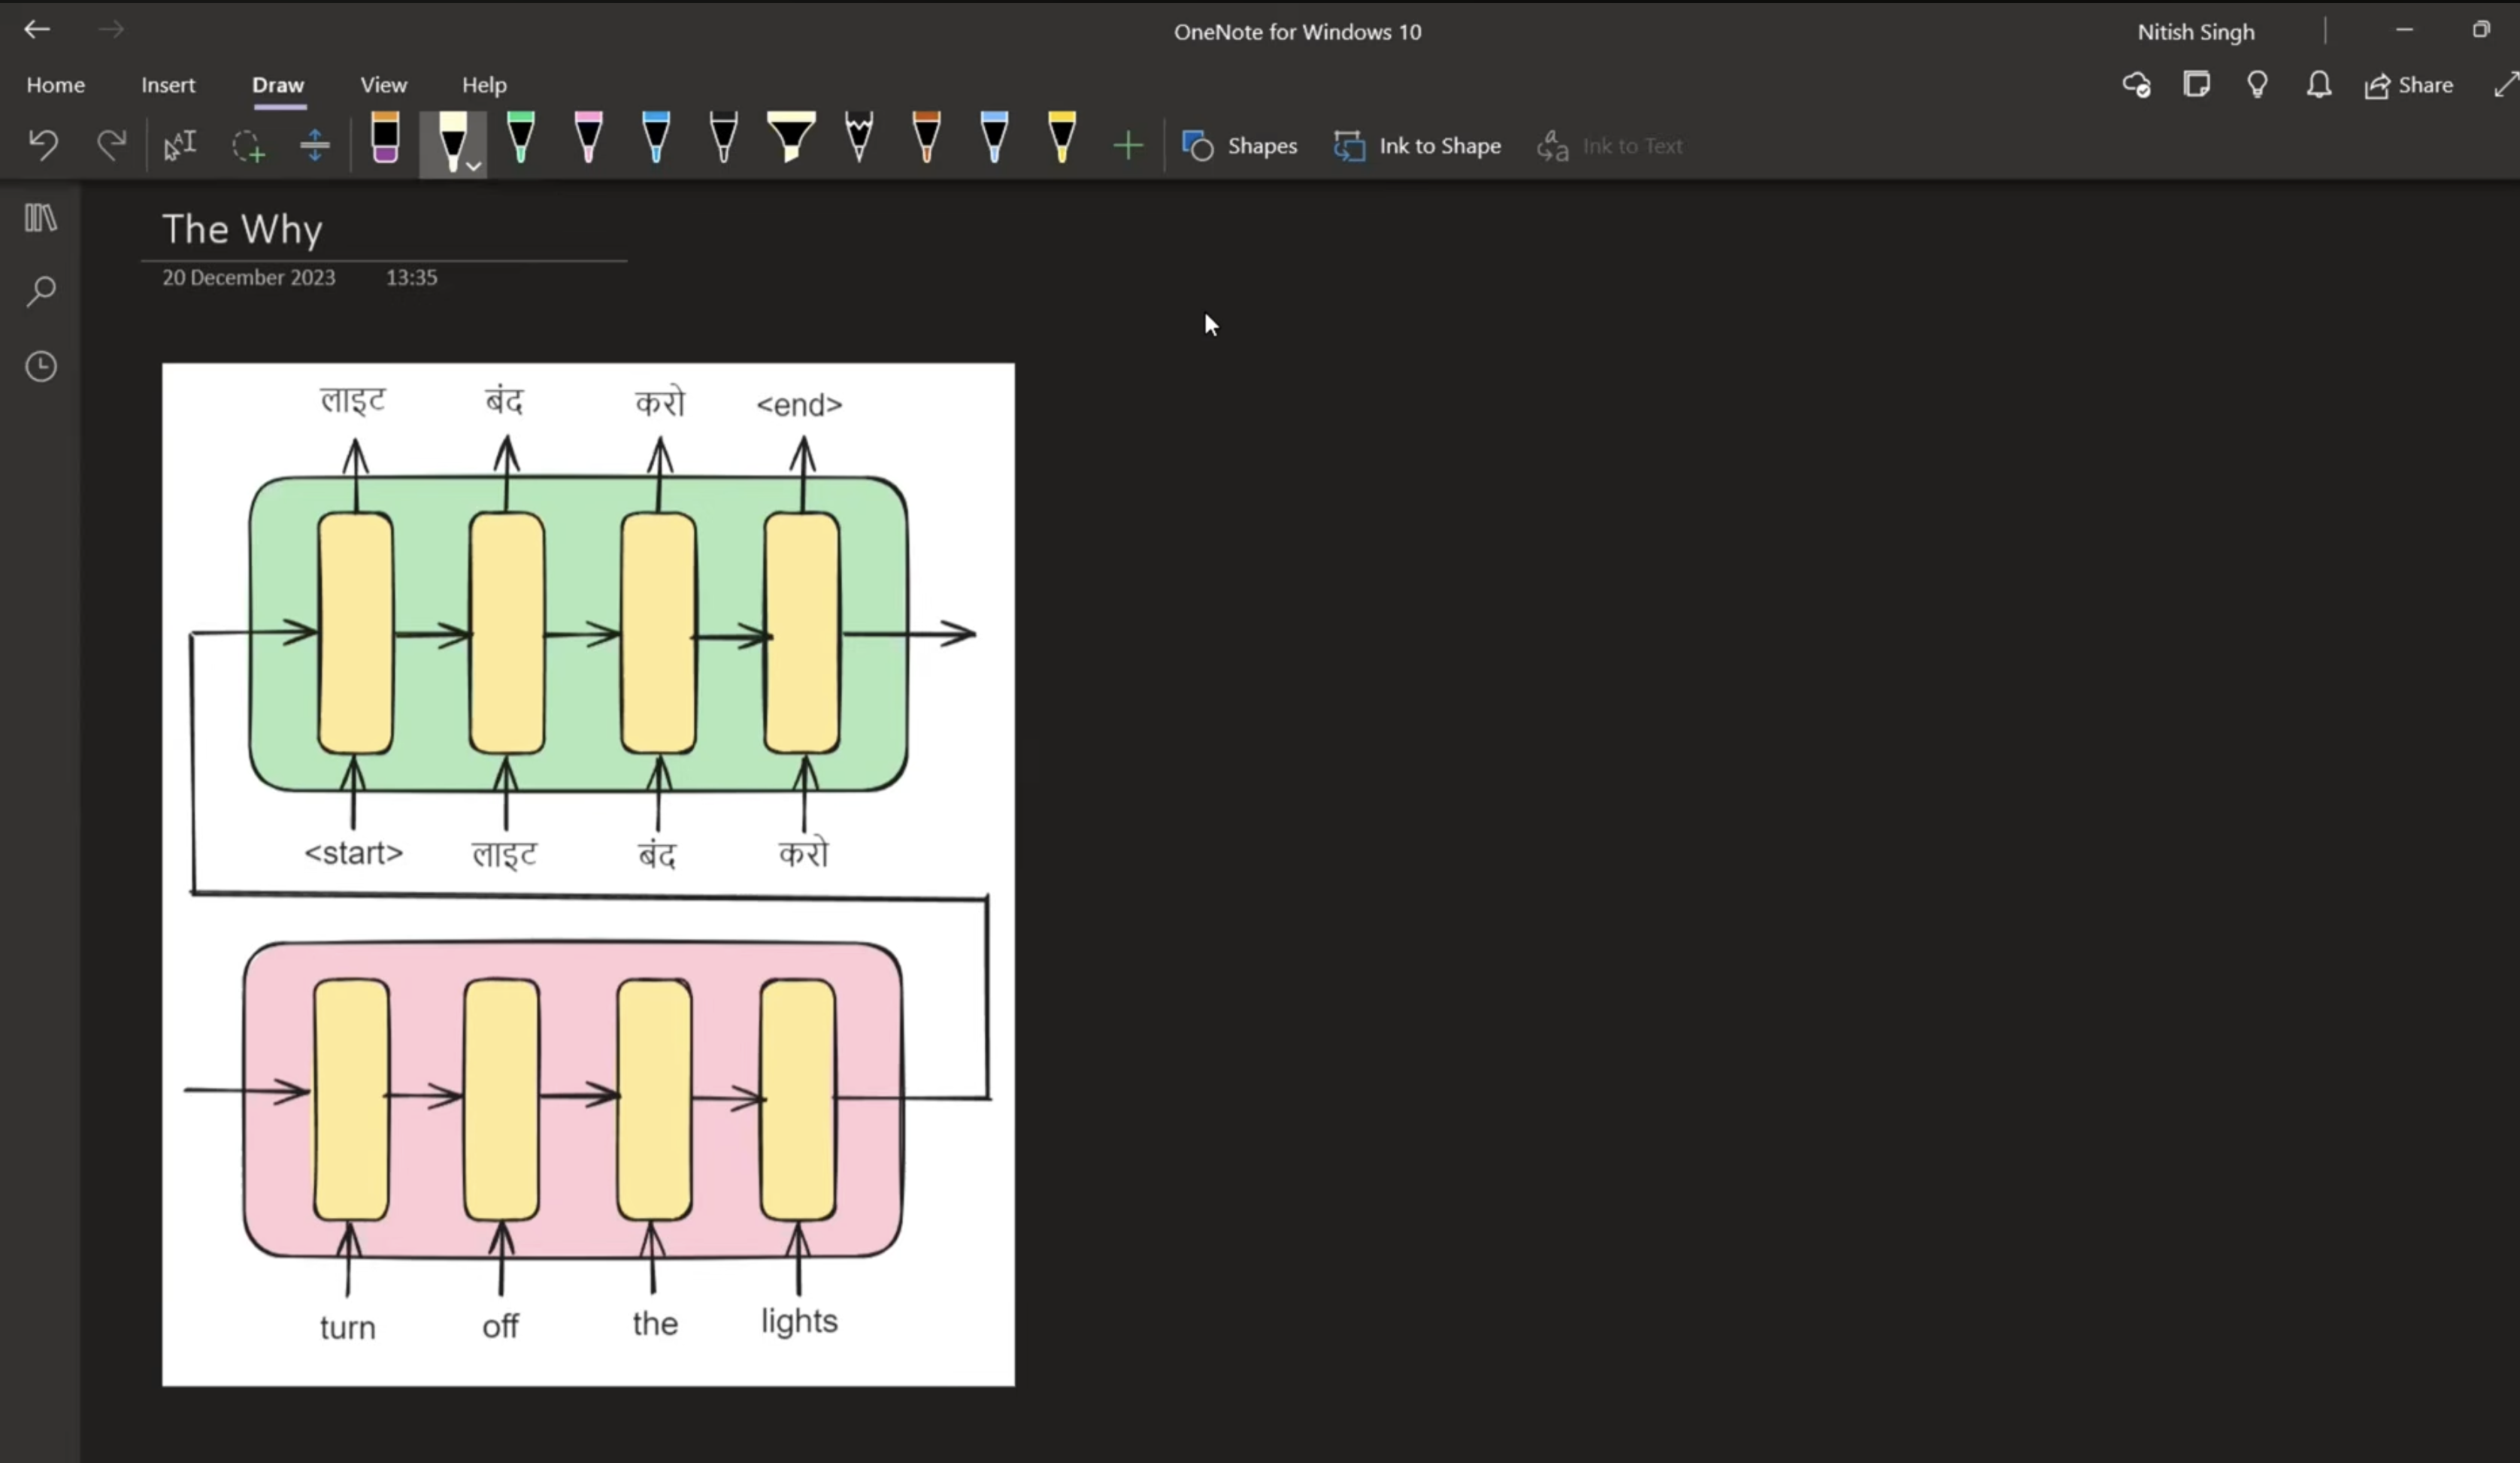

Before understanding the problem, let's recap how a basic Encoder-Decoder works:

| Component | Role |
|-----------|------|
| **Encoder** (pink block) | Processes the input sentence step-by-step and generates a **summary vector** (a fixed-size representation of the entire sentence) |
| **Decoder** (green block) | Takes this summary vector and generates the output sentence word-by-word |

**How it works (step by step):**
1. You feed an input sentence (e.g., "turn off the lights") into the encoder
2. The encoder reads it word by word (time steps 1, 2, 3, 4...)
3. After processing everything, the encoder produces a **single summary vector** (a set of numbers)
4. This summary vector is passed to the decoder
5. The decoder uses this vector to print the translated output word by word

#### The Two Major Problems

**Problem 1: Encoder Overload**

Imagine someone gives you a 50-word sentence in English, asks you to read it once, close your eyes, and translate it entirely into Hindi. 

> Most people cannot do this! The sentence is simply too long to hold in memory perfectly.

The same happens with Encoder-Decoder:
- The encoder is forced to compress the **entire sentence** into a **small summary vector**
- For sentences longer than ~25 words, this summary becomes **overloaded**
- A small set of numbers cannot capture all the nuance of a long sentence

> **Key insight:** We're putting too much pressure on the encoder to "remember" everything perfectly in one go.

**Problem 2: Decoder Confusion**

Now think about the decoder's perspective. When translating "turn off the lights" to Hindi:

| Output Word | Which input words are actually needed? |
|-------------|----------------------------------------|
| "light" (first word) | Only the word "lights" from the input |
| "off" (second word) | Only "turn" and "off" |
| "karo" (third word) | Depends on context |

**The issue:** The decoder receives the **entire summary vector** at every time step, even though it only needs specific parts of the input sentence for each output word.

> **Key insight:** The summary vector is **static** — it doesn't change across time steps. This makes it hard for the decoder to "zoom in" on the relevant parts.

#### What Humans Do Differently

When humans translate long text:
- We don't memorize the entire sentence at once
- We have an **attention span** — our focus stays on a specific region
- As we move forward, our attention shifts; the region ahead becomes clear, and the rest becomes "blurry"
- We translate **on-the-go**, using context from around where we currently are

#### The Solution: Attention Mechanism

Instead of giving the decoder the **same static summary** at every step, attention allows the decoder to **dynamically look at** different parts of the input sentence at each time step.

**Example:**
- At time step 1 (printing "light"): Tell the decoder that **h4** (the hidden state for "lights") is most important
- At time step 2 (printing "off"): Tell the decoder that **h1** and **h2** (hidden states for "turn" and "off") are most important

This dynamic focus is exactly what the **Attention Mechanism** provides.

---

### 3. Key Points

- The basic Encoder-Decoder uses a **single static summary vector** for the entire input
- This works for short sentences but fails for long ones (over ~25 words)
- **Problem 1:** Encoder is overloaded — it must compress everything into a small vector
- **Problem 2:** Decoder receives the same summary at every step, even though different words need different context
- Humans translate by **shifting attention** to relevant parts of the text
- **Attention Mechanism** solves both problems by giving the decoder **dynamic, time-step-specific** information about which encoder hidden states are useful

---

### 4. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|----------------|--------------|
| Thinking Encoder-Decoder works well for all sentences | It fails for long sentences due to information bottleneck | Remember the 30-word threshold from the paper's BLEU score graph |
| Assuming the decoder needs the entire sentence for every word | Different output words depend on different input parts | Think of how you would translate — you'd only look at relevant words |
| Forgetting that the summary is static | The decoder gets the same vector at every step, which limits its ability to focus | Contrast this with attention, where the input changes dynamically |

---

### 5. Interview/Exam Questions

**Q1: What is the main problem with the basic Encoder-Decoder architecture?**
> **Answer:** It uses a single static summary vector to represent the entire input sentence. For long sentences, this vector gets overloaded and loses information. Also, the decoder gets the same summary at every time step, even though different output words need to focus on different parts of the input.

**Q2: Why do humans translate better than the basic Encoder-Decoder model?**
> **Answer:** Humans don't memorize the entire sentence at once. We have an attention span and shift our focus to relevant parts as we translate. We translate "on-the-go" using local context.

**Q3: What is the core idea behind the Attention Mechanism?**
> **Answer:** Instead of giving the decoder one static summary vector, attention provides a **dynamic context vector** at each time step that tells the decoder which encoder hidden states are most relevant for generating the current output word.

---

### 6. Revision Notes (Quick Recap)

| Concept | Key Takeaway |
|---------|--------------|
| **Encoder-Decoder** | Takes input → generates summary → decoder generates output |
| **Summary vector** | Fixed-size representation of entire input — bottleneck for long sentences |
| **Encoder overload** | Too much information compressed into too few numbers |
| **Decoder confusion** | Gets same summary at every step, can't focus on relevant parts |
| **Human translation** | Uses attention span; shifts focus as we move through text |
| **Attention Mechanism** | Provides dynamic context at each decoder step; tells decoder which encoder states matter |

---



## Topic 2: Core Concepts of Attention – Context Vectors, Weights, and Weighted Sum

---

### 1. Introduction

Now that we understand *why* we need attention, let's understand *how* it actually works at a conceptual level. 

The attention mechanism is built around a simple but powerful idea: **at every decoding step, we calculate a special vector called the context vector** that tells the decoder which parts of the input to focus on. This context vector is created by taking a **weighted sum** of all encoder hidden states.

**Why this matters:** This is the mathematical heart of attention. Once you understand how the context vector is built and what the weights mean, you've understood the core of the entire mechanism.

---

### 2. Detailed Explanation
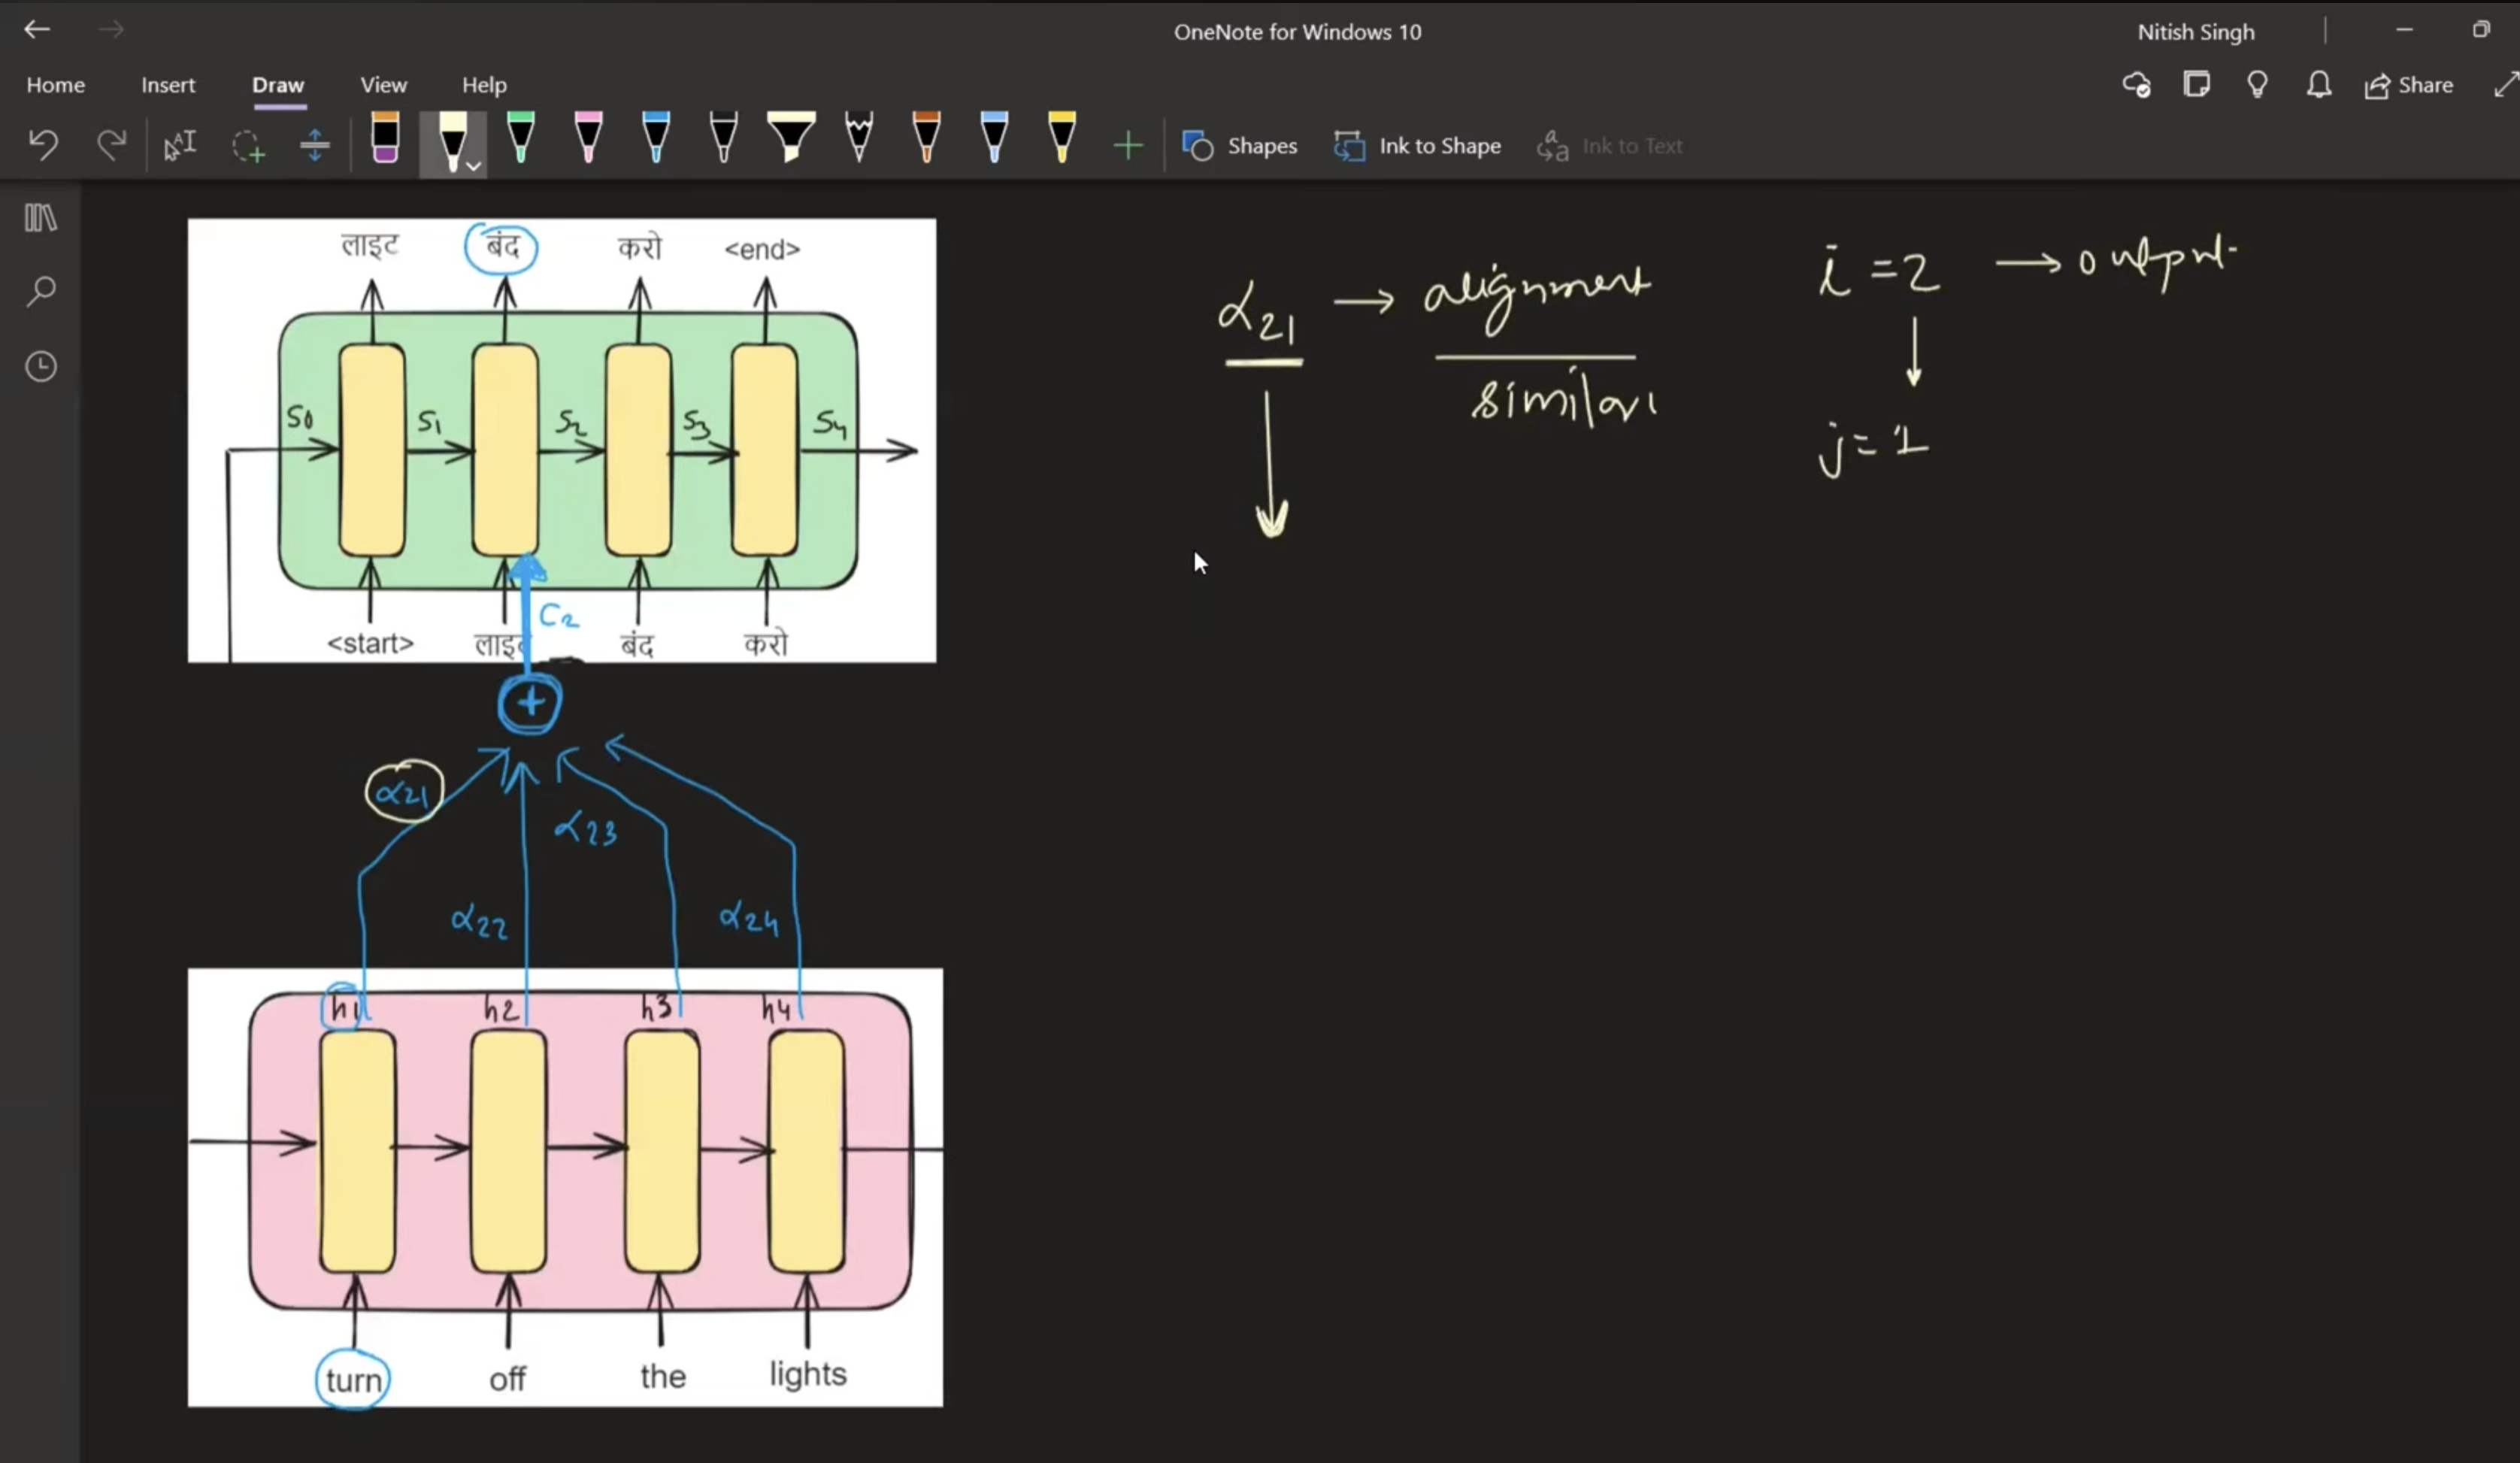
#### Setting Up the Notation

Before diving in, let's label all the parts of our Encoder-Decoder with attention:

| Symbol | What it represents |
|--------|-------------------|
| **h₁, h₂, h₃, h₄** | Hidden states of the **encoder** (one per input word) |
| **s₁, s₂, s₃, s₄** | Hidden states of the **decoder** (one per output word) |
| **y₀, y₁, y₂, y₃** | Inputs to the decoder (via teacher forcing - the correct previous output) |
| **c₁, c₂, c₃, c₄** | **Attention inputs** - the context vectors fed to the decoder at each step |

**Important change:** In the basic Encoder-Decoder, at each decoder time step, we needed **two** inputs:
1. The previous decoder state (sᵢ₋₁)
2. The input word via teacher forcing (yᵢ₋₁)

With attention, we now need **three** inputs at each decoder time step:
1. The previous decoder state (sᵢ₋₁)
2. The input word via teacher forcing (yᵢ₋₁)
3. **The attention context vector (cᵢ)** ← NEW!

#### What Exactly is the Context Vector (cᵢ)?

The context vector **cᵢ** tells the decoder: "For the word you're about to generate at time step *i*, here's the relevant information from the input sentence."

**Key properties of cᵢ:**
- It is a **vector** (same dimensions as each encoder hidden state)
- Its purpose is to **pick up and combine** the useful encoder hidden states
- It changes at every decoder time step (dynamic!)

**Example:** At time step 1 (c₁), we want to tell the decoder that **h₄** (the hidden state for "lights") is most useful for generating the word "light."

#### How Do We Build the Context Vector?

We don't just pick one hidden state — we use **all** encoder hidden states, but we give them **different importance weights**.

Here's the process:

1. **Assign weights** to each encoder hidden state:
   - h₁ gets weight α₁ (alpha 1)
   - h₂ gets weight α₂
   - h₃ gets weight α₃
   - h₄ gets weight α₄

2. **Calculate the weighted sum:**
   
   > **cᵢ = α₁·h₁ + α₂·h₂ + α₃·h₃ + α₄·h₄**

3. The weights (α values) are **scalars** (single numbers) that determine importance

4. The resulting context vector **cᵢ** has the same dimension as each h (since we're combining vectors of the same size)

**Important:** If h₁, h₂, h₃, h₄ are all 4-dimensional vectors, then cᵢ is also 4-dimensional! Even if we combine multiple hidden states, we use a weighted sum, so the dimension remains the same.

#### What Do the Weights Mean?

Let's say for c₁, the weights are:
- α₁ = 0.05 (very small → h₁ is not useful)
- α₂ = 0.05 (very small → h₂ is not useful)
- α₃ = 0.10 (small → h₃ is slightly useful)
- α₄ = 0.80 (very large → h₄ is most useful!)

When we calculate c₁ = 0.05·h₁ + 0.05·h₂ + 0.10·h₃ + 0.80·h₄, the resulting vector will be **dominated by h₄**. This effectively tells the decoder: "Pay attention to h₄ — it represents the word 'lights'!"

#### General Formula

Let:
- **i** = decoder time step (1, 2, 3, 4...)
- **j** = encoder time step (1, 2, 3, 4...)

Then:
> **cᵢ = Σⱼ αᵢⱼ · hⱼ**

This means: to calculate cᵢ, we sum over all encoder time steps j, multiplying each hidden state hⱼ by its weight αᵢⱼ.

#### How Many Weights Do We Need?

For a sentence with 4 input words and 4 output words:

| Context Vector | Weights needed |
|----------------|----------------|
| c₁ (for output word 1) | α₁₁, α₁₂, α₁₃, α₁₄ |
| c₂ (for output word 2) | α₂₁, α₂₂, α₂₃, α₂₄ |
| c₃ (for output word 3) | α₃₁, α₃₂, α₃₃, α₃₄ |
| c₄ (for output word 4) | α₄₁, α₄₂, α₄₃, α₄₄ |

**Total:** 4 × 4 = **16 weights** (αᵢⱼ where i × j)

In general, if you have **T_encoder** time steps and **T_decoder** time steps, you need **T_encoder × T_decoder** weights.

---

### 3. Key Points

| Concept | Explanation |
|---------|-------------|
| **Context vector (cᵢ)** | Dynamic vector fed to decoder at each time step; tells decoder which input parts to focus on |
| **Weighted sum** | Context vector = sum of all encoder hidden states × their importance weights |
| **Weights (αᵢⱼ)** | Scalars that indicate how much encoder step j contributes to decoder step i |
| **Dimension** | cᵢ has the same dimension as each encoder hidden state |
| **Dynamic nature** | Each decoder step gets a different context vector (different weights) |
| **Total weights** | Number of decoder steps × number of encoder steps |

**Example with "turn off the lights":**

| Decoder Step | Most important encoder hidden state(s) | Why |
|--------------|----------------------------------------|-----|
| c₁ (output "light") | h₄ ("lights") | We need to know what to turn off |
| c₂ (output "off") | h₁ + h₂ ("turn" + "off") | We need the action phrase |
| c₃ (output "karo") | Multiple states | Depends on context |
| c₄ (output "end") | Multiple states | Complete translation |

---

### 4. Common Mistakes

| Mistake | Why it's wrong | Correct understanding |
|---------|----------------|----------------------|
| "Context vector picks the most relevant hidden state" | It uses ALL hidden states, just with different weights | The vector is a weighted sum of ALL encoder states |
| "The context vector can have any dimension" | It must match the dimension of encoder hidden states | Weighted sum of same-dimension vectors yields same dimension |
| "Weights are fixed" | Weights change at every decoder step | Each cᵢ has its own set of weights (αᵢ₁, αᵢ₂, ...) |
| "Context vector is a single number" | It's a vector, not a scalar | It's a set of numbers (same dimension as hidden states) |

---

### 5. Interview/Exam Questions

**Q1: What is the context vector in the attention mechanism?**
> **Answer:** The context vector cᵢ is a dynamic vector fed to the decoder at time step i. It is calculated as a weighted sum of all encoder hidden states: cᵢ = Σⱼ αᵢⱼ · hⱼ. The weights αᵢⱼ indicate how relevant encoder step j is for generating the output at decoder step i.

**Q2: How do you calculate the context vector for the second output word?**
> **Answer:** c₂ = α₂₁·h₁ + α₂₂·h₂ + α₂₃·h₃ + α₂₄·h₄, where the α values are the attention weights specifically for decoder step 2.

**Q3: If the encoder hidden states have dimension 256, what is the dimension of the context vector?**
> **Answer:** 256. The context vector is a weighted sum of the encoder hidden states, and the weighted sum of vectors of the same dimension results in a vector of that same dimension.

**Q4: How many attention weights are needed if the input sentence has 10 words and the output has 8 words?**
> **Answer:** 10 × 8 = 80 attention weights.

---

### 6. Revision Notes (Quick Recap)

```
Context Vector Formula:
cᵢ = αᵢ₁·h₁ + αᵢ₂·h₂ + ... + αᵢₙ·hₙ
     └── weight for h₁ ──┘   └── hₙ is nth encoder state ──┘

Where:
• i = decoder time step
• αᵢⱼ = attention weight (scalar) 
• hⱼ = encoder hidden state (vector)
• cᵢ = context vector (vector)
```

**Key takeaways:**
- Attention adds a **third input** to the decoder: cᵢ
- cᵢ is a **weighted sum** of all encoder hidden states
- Each decoder step gets **its own set of weights**
- Weights tell us **which input words matter most**
- The context vector has the **same dimension** as encoder hidden states

---



## Topic 3: Calculating Attention Weights – The Alignment Model (How α Values Are Generated)

---

### 1. Introduction

We now know that attention weights (αᵢⱼ) are the key to building the context vector. But how do we actually calculate these weights? This is where the **alignment model** comes in — a clever approach that uses a small neural network to learn the "similarity" or "alignment" between encoder and decoder states.

**Why this matters:** The alignment model is what makes attention "learnable." Instead of manually defining how to calculate weights, we let the model figure it out from data, making it adaptable to any language pair or task.

---

### 2. Detailed Explanation

#### What Does αᵢⱼ Represent?

Let's start with a specific example: **α₂₁** (alpha 2,1)

> α₂₁ is an **alignment score** (or similarity score) that tells us: *How much does encoder time step 1 (h₁ / "turn") contribute to generating the output at decoder time step 2 ("off")?*

**In simple terms:** α₂₁ answers the question — "How relevant is the first input word for producing the second output word?"

#### What Does αᵢⱼ Depend On?

To calculate α₂₁, we need to consider:

| Quantity | Symbol | Why it's needed |
|----------|--------|-----------------|
| **Encoder hidden state** | h₁ | We're measuring similarity to this state |
| **Previous decoder state** | s₁ | We need context of what translation has already happened |

**But wait — why the previous decoder state (s₁) and not the current one?**

This is a common point of confusion! Here's the logic:

> When we're at decoder time step 2, we want to know: *Given that we've already translated the first word ("light"), how relevant is h₁ ("turn") for translating the second word ("off")?*

The previous decoder state (s₁) captures **what has already been translated**. We use this as context to determine what we need next.

**General rule:** αᵢⱼ is a function of:
- **hⱼ** (encoder state at position j)
- **sᵢ₋₁** (previous decoder state)

> αᵢⱼ = f(hⱼ, sᵢ₋₁)

**Examples:**
- α₂₁ = f(h₁, s₁)
- α₂₃ = f(h₃, s₁)
- α₃₂ = f(h₂, s₂)

#### How Do We Define the Function f?

This is the big question! What mathematical function should we use to combine hⱼ and sᵢ₋₁ to produce αᵢⱼ?

**The challenge:** There's no obvious mathematical formula. Different functions could work for different tasks.

**The brilliant solution:** Instead of manually defining a function, researchers used a **neural network**!

> **Key insight:** Neural networks are **universal function approximators** — with enough data and training, they can approximate ANY function.

**How it works:**
1. Replace the unknown mathematical function with a **small feedforward neural network**
2. Give it two inputs: hⱼ and sᵢ₋₁
3. The output of the network is αᵢⱼ
4. Let the network **learn** the right function during training!

#### Visualizing the Alignment Model

```
                      ┌─────────────────┐
        h₁ ──────────►│                 │
                      │  Neural Network │────► α₂₁
        s₁ ──────────►│    (Alignment   │
                      │     Model)      │
                      └─────────────────┘
```

This same network is reused for **every** pair of encoder and decoder states. For example:

| Weight | Inputs | Network Output |
|--------|--------|----------------|
| α₂₁ | h₁, s₁ | α₂₁ |
| α₂₂ | h₂, s₁ | α₂₂ |
| α₂₃ | h₃, s₁ | α₂₃ |
| α₂₄ | h₄, s₁ | α₂₄ |

The network's weights are **shared** across all calculations — it's the same network used repeatedly!

#### The Complete Picture for Calculating c₂

Let's see how this all comes together for decoder step 2 (generating "off"):

**Step 1:** For each encoder time step, feed the pair into the alignment network:

| Pair | Input to Network | Output | Interpretation |
|------|------------------|--------|----------------|
| (h₁, s₁) | h₁ and s₁ | α₂₁ | Relevance of "turn" for "off" |
| (h₂, s₁) | h₂ and s₁ | α₂₂ | Relevance of "off" for "off" |
| (h₃, s₁) | h₃ and s₁ | α₂₃ | Relevance of "the" for "off" |
| (h₄, s₁) | h₄ and s₁ | α₂₄ | Relevance of "lights" for "off" |

**Step 2:** Calculate the context vector:
> c₂ = α₂₁·h₁ + α₂₂·h₂ + α₂₃·h₃ + α₂₄·h₄

**Step 3:** Feed c₂ (along with s₁ and y₁) into the decoder to produce the next state s₂ and generate "off."

#### How Is the Alignment Network Trained?

The beauty of this approach is that the alignment network is **trained end-to-end** with the entire Encoder-Decoder:

1. The whole system (encoder + attention network + decoder) is trained together
2. Backpropagation through time adjusts not only the LSTM weights but also the **weights and biases of the alignment network**
3. Since all training happens in one go, the alignment network learns the correct weights to calculate good attention scores

> **Key point:** We don't need separate training for the alignment network — it learns automatically as part of the larger system!

---

### 3. Key Points

| Concept | Explanation |
|---------|-------------|
| **Alignment score (αᵢⱼ)** | A score indicating how well encoder step j aligns with decoder step i |
| **What α depends on** | αᵢⱼ = f(hⱼ, sᵢ₋₁) — function of encoder hidden state and previous decoder state |
| **Why use previous decoder state** | It captures what has already been translated, providing context |
| **Alignment model** | A feedforward neural network that computes αᵢⱼ from hⱼ and sᵢ₋₁ |
| **Network reuse** | The same network is used for all (i, j) pairs |
| **End-to-end training** | The alignment network trains together with the entire architecture |
| **Universal approximation** | Neural networks can learn any function, so we don't need to manually define the math |

**The Alignment Model in One Line:**
> αᵢⱼ = NeuralNetwork(hⱼ, sᵢ₋₁)

---

### 4. Common Mistakes

| Mistake | Why it's wrong | Correct understanding |
|---------|----------------|----------------------|
| "αᵢⱼ depends on the current decoder state" | We use the PREVIOUS decoder state because current isn't available yet | αᵢⱼ = f(hⱼ, sᵢ₋₁), not sᵢ |
| "We need a different network for each α" | The same network is reused | The network's weights are shared across all pairs |
| "The network only uses hⱼ" | It uses BOTH hⱼ and sᵢ₋₁ | Both inputs are necessary for alignment |
| "We must define the mathematical function ourselves" | We let the neural network learn it | Neural networks are universal approximators that learn from data |

---

### 5. Interview/Exam Questions

**Q1: What is an alignment score in the context of attention?**
> **Answer:** An alignment score αᵢⱼ measures how relevant encoder hidden state hⱼ (at time step j) is for generating the output at decoder time step i. It tells the decoder which input words to focus on.

**Q2: How is αᵢⱼ calculated?**
> **Answer:** αᵢⱼ is the output of a neural network that takes two inputs: the encoder hidden state hⱼ and the previous decoder state sᵢ₋₁. So αᵢⱼ = NN(hⱼ, sᵢ₋₁).

**Q3: Why do we use the previous decoder state (sᵢ₋₁) rather than the current one (sᵢ) to calculate attention weights?**
> **Answer:** Because at the time we're calculating the context vector for time step i, the current decoder state sᵢ hasn't been computed yet. Using sᵢ₋₁ captures the context of what has already been translated, which helps determine what's needed next.

**Q4: How does the alignment network get trained?**
> **Answer:** It's trained end-to-end with the entire encoder-decoder architecture. Backpropagation through time adjusts the weights of the alignment network along with the LSTM weights, allowing it to learn the appropriate function from the training data.

**Q5: What is the advantage of using a neural network instead of a fixed mathematical function for alignment?**
> **Answer:** Neural networks are universal function approximators that can learn any function from data. This makes the approach flexible and adaptable to different tasks/languages, without needing to manually design the right mathematical formula.

---

### 6. Revision Notes (Quick Recap)

```
ALIGNMENT MODEL:

αᵢⱼ = NeuralNetwork(hⱼ, sᵢ₋₁)
       └─────┬─────┘
             │
    ┌────────┴────────┐
    │  Inputs:        │
    │  • hⱼ (encoder) │
    │  • sᵢ₋₁ (decoder│
    │     previous)   │
    └─────────────────┘
```

**Process Summary:**
1. For each decoder time step i:
   - Take previous decoder state sᵢ₋₁
   - For each encoder time step j:
     - Feed (hⱼ, sᵢ₋₁) into alignment network → get αᵢⱼ
   - All αᵢⱼ values give us a weight for each encoder state
   - Compute cᵢ = Σⱼ αᵢⱼ·hⱼ
   - Feed cᵢ to decoder to generate output

**Remember:**
- Same network, reused for all pairs
- Trained end-to-end with everything else
- No manual function design needed!

---



## Topic 4: Complete Attention Architecture in Action + Proof It Works

---

### 1. Introduction

We now have all the pieces: the context vector, the attention weights, and the alignment model. In this final topic, we'll see how everything comes together in a complete step-by-step walkthrough of the attention mechanism during translation. We'll also look at the experimental evidence proving that attention actually works, including BLEU score graphs and visualizations of attention weights.

**Why this matters:** Understanding the complete flow solidifies all the concepts and shows you exactly what happens at every time step. The visual proof gives you confidence that this complex architecture is worth the effort!

---

### 2. Detailed Explanation

#### Step-by-Step: Complete Attention Architecture at Decoder Time Step 2

Let's walk through the entire process for generating the second output word ("off") from the input sentence "turn off the lights" (encoded as h₁, h₂, h₃, h₄).

**Assumption:** We've already generated the first output word "light" at decoder step 1, so we're now at the second time step (i = 2).

---

**Step 1: Get the previous decoder state**
- We have s₁ from the previous time step (the decoder's internal state after generating "light")

---

**Step 2: Calculate all attention weights for this time step**

Using the alignment network, we calculate all four α values for c₂:

| Weight | Inputs to Network | Network Output | Meaning |
|--------|-------------------|----------------|---------|
| α₂₁ | h₁ and s₁ | (some value) | How much does "turn" help generate "off"? |
| α₂₂ | h₂ and s₁ | (some value) | How much does "off" help generate "off"? |
| α₂₃ | h₃ and s₁ | (some value) | How much does "the" help generate "off"? |
| α₂₄ | h₄ and s₁ | (some value) | How much does "lights" help generate "off"? |

**Expected result:** α₂₁ and α₂₂ should be high (since "turn off" is the relevant phrase), while α₂₃ and α₂₄ should be low.

---

**Step 3: Calculate the context vector**

> **c₂ = α₂₁·h₁ + α₂₂·h₂ + α₂₃·h₃ + α₂₄·h₄**

Since α₂₁ and α₂₂ dominate, c₂ will be heavily influenced by h₁ and h₂ — exactly what we want for generating "off"!

---

**Step 4: Feed three inputs to the decoder at time step 2**

The decoder receives all three inputs simultaneously:

| Input | Source | Purpose |
|-------|--------|---------|
| **c₂** | Context vector we just calculated | Tells decoder which input words to focus on |
| **s₁** | Previous decoder state | Provides context of what was already translated |
| **y₁** (="light") | Teacher forcing (correct previous word) | Provides the actual previous output |

---

**Step 5: The decoder processes these three inputs**

The decoder LSTM uses these three inputs to:
1. Compute its new internal state: **s₂**
2. Generate the output word: **"off"**

---

**Step 6: Repeat for remaining time steps**

The same process repeats for:
- Time step 3: Calculate α₃₁, α₃₂, α₃₃, α₃₄ → c₃ → generate "karo"
- Time step 4: Calculate α₄₁, α₄₂, α₄₃, α₄₄ → c₄ → generate "end" (translation complete)

---

#### Visual Flow Summary

```
Encoder:     h₁ ──── h₂ ──── h₃ ──── h₄
                │       │       │       │
                ▼       ▼       ▼       ▼
Attention:   [α₂₁]   [α₂₂]   [α₂₃]   [α₂₄]  ← from Alignment Network
                │       │       │       │
                └───────┼───────┼───────┘
                        ▼
               c₂ = weighted sum
                        │
                ┌───────┼───────┐
                ▼       ▼       ▼
Decoder:   [c₂]   +   [s₁]  +  [y₁]  →  s₂ → output "off"
```

#### The Change: 2 Inputs → 3 Inputs

| Architecture | Inputs to Decoder at Each Time Step |
|--------------|--------------------------------------|
| **Basic Encoder-Decoder** | sᵢ₋₁ (previous state) + yᵢ₋₁ (previous word) |
| **With Attention** | sᵢ₋₁ (previous state) + yᵢ₋₁ (previous word) + **cᵢ (context vector)** |

---

#### Proof That Attention Works

**1. BLEU Score Comparison**

BLEU (Bilingual Evaluation Understudy) is a metric that measures translation quality (higher = better).

The graph from the original attention paper showed:

| Model Type | Performance |
|------------|-------------|
| Most models without attention | BLEU score drops rapidly after sentence length > 30 words |
| **Attention-based model** | BLEU score remains **stable** even after 30 words! |

> **Key finding:** Attention doesn't necessarily increase BLEU scores for short sentences, but it **prevents the drop in quality** for long sentences. This proves attention solves the "long sentence problem."

**2. Visualization of Attention Weights**

Since we have all the α values (16 for a 4×4 translation), we can plot them as a heatmap:

```
               English Words
           turn   off    the   lights
            │      │      │      │
    light   │ 0.01  0.01  0.01  0.97 │  ← 97% weight on "lights"
    off     │ 0.48  0.48  0.02  0.02 │  ← equally on "turn"+"off"
French  karo │ 0.25  0.25  0.25  0.25 │  ← spread across all
    end     │ 0.01  0.01  0.97  0.01 │  ← mostly on "the"
```

**What this visualization proves:**
- The model is actually **looking at the right places**
- For translating "light" (French: "lumière"), it focuses on "lights" (97% weight)
- For translating "off" (French: "éteindre"), it focuses on "turn" and "off" together
- This matches how a human translator would work!

**Example from the original paper (English → French):**
- The word "European" aligned strongly with its French translation
- "Accord" aligned with its French counterpart
- "Zone" had some alignment with "La" as well

This grid visualization gives us **confidence** that:
1. The model is learning meaningful alignments
2. The attention mechanism is actually working as intended
3. The heavy theory behind it is paying off!

---

#### Bonus: Bidirectional LSTM in the Original Paper

The original attention paper used **bidirectional LSTMs** in the encoder:

| Feature | Benefit |
|---------|---------|
| **Bidirectional Encoder** | At any time step, the model has access to BOTH past and future context |
| **Unidirectional Decoder** | Only the encoder uses bidirectional LSTM |

**Why use bidirectional encoders?**
- For each input word, you get context from both directions
- This improves translation quality because word meaning depends on surrounding words

**Important:** Using bidirectional LSTM doesn't change the attention mechanism itself. The alignment model and context vector calculations remain exactly the same!

---

### 3. Key Points

| Concept | Summary |
|---------|---------|
| **Complete flow** | For each decoder step: (1) calculate α weights, (2) compute cᵢ, (3) feed cᵢ + sᵢ₋₁ + yᵢ₋₁ to decoder |
| **Dynamic focus** | Each decoder step gets different attention weights and a different context vector |
| **Three inputs** | Attention adds the context vector to the two existing decoder inputs |
| **BLEU score proof** | Attention keeps translation quality stable for sentences beyond 30 words |
| **Visual proof** | Heatmaps show the model focusing on the correct input words for each output word |
| **Bidirectional LSTM** | Used in the original paper for the encoder only; provides better context |

---

### 4. Common Mistakes

| Mistake | Why it's wrong | Correct understanding |
|---------|----------------|----------------------|
| "The decoder gets cᵢ INSTEAD of the summary" | It gets cᵢ IN ADDITION to the previous state and previous word | Three inputs now, not two |
| "Attention weights are calculated once" | They're recalculated at EVERY decoder time step | Each i has its own set of αᵢⱼ values |
| "BLEU scores always improve with attention" | Attention prevents degradation for long sentences; may not improve short ones | Attention SOLVES the long-sentence problem, it doesn't magically make everything better |
| "Attention weights only show which words matter" | They show nuanced alignment patterns | The heatmaps reveal interpretable, human-like alignment relationships |

---

### 5. Interview/Exam Questions

**Q1: Walk me through the complete process of generating the third output word using attention.**
> **Answer:** For decoder time step 3: (1) Get previous decoder state s₂. (2) Feed (h₁,s₂), (h₂,s₂), (h₃,s₂), (h₄,s₂) into the alignment network to get α₃₁, α₃₂, α₃₃, α₃₄. (3) Calculate c₃ = α₃₁·h₁ + α₃₂·h₂ + α₃₃·h₃ + α₃₄·h₄. (4) Feed c₃, s₂, and y₂ (teacher forcing) into the decoder to produce s₃ and generate the third output word.

**Q2: What evidence proves that attention actually works?**
> **Answer:** Two main pieces of evidence: (1) BLEU score graphs show that attention-based models maintain translation quality even for long sentences (>30 words), while non-attention models degrade rapidly. (2) Visualization of attention weights (heatmaps) shows the model focusing on the correct input words when generating each output word, matching human translation behavior.

**Q3: How many inputs does the decoder receive at each time step with attention, and what are they?**
> **Answer:** Three inputs: (1) the previous decoder state sᵢ₋₁, (2) the previous output word via teacher forcing yᵢ₋₁, and (3) the context vector cᵢ. This is one more input than the basic encoder-decoder architecture.

**Q4: Did the original attention paper use bidirectional LSTMs? Where?**
> **Answer:** Yes, the original paper used bidirectional LSTMs for the ENCODER only (not the decoder). This gives the encoder access to both past and future context for each input word, improving translation quality.

**Q5: What is the difference between how basic encoder-decoder and attention-based models handle long sentences?**
> **Answer:** Basic encoder-decoder forces the entire sentence into a single static summary vector, which loses information for long sentences. Attention-based models dynamically look at different parts of the input at each output step, creating multiple context vectors that can handle much longer sequences effectively.

---

### 6. Revision Notes (Quick Recap)

**Complete Attention Flow (One Time Step):**

```
For decoder step i:
  1. Get sᵢ₋₁ (previous state)
  2. For each j: αᵢⱼ = NN(hⱼ, sᵢ₋₁)
  3. cᵢ = Σⱼ αᵢⱼ·hⱼ
  4. Feed (cᵢ, sᵢ₋₁, yᵢ₋₁) → decoder → generate output
  5. Repeat for next time step
```

**Proof It Works:**
- 📈 BLEU scores stay stable for long sentences
- 🎯 Heatmaps show correct alignments
- 🧠 Matches human translation behavior

**Key Change:**
- Basic: 2 decoder inputs (sᵢ₋₁, yᵢ₋₁)
- Attention: 3 decoder inputs (cᵢ, sᵢ₋₁, yᵢ₋₁)

---

### 🎯 Final Summary of the Entire Series

| Topic | Key Takeaway |
|-------|--------------|
| **Why we need attention** | Encoder-Decoder fails on long sentences due to static summary and decoder confusion |
| **Context vectors & weights** | cᵢ = weighted sum of hⱼ; weights determine importance |
| **Alignment model** | αᵢⱼ = NN(hⱼ, sᵢ₋₁) — neural network learns to calculate weights |
| **Complete architecture** | 3 inputs to decoder; dynamic focus at every step; BLEU and heatmaps prove it works |

---

**That concludes all topics on the Attention Mechanism!** 🎉

